<a id="top"></a>
<div class="list-group" id="list-tab" role="tablist">
<h1 class="list-group-item list-group-item-action active" data-toggle="list" style='background:#005097; border:0; color:white; padding:15px' role="tab" aria-controls="home"><center>Inferência Estatística (GCC1625) - Trabalho 1</center></h1>

- **Nome completo:** GUSTAVO ARRUDA BITTENCOURT
- **Link para vídeo:** https://www.youtube.com/watch?v=mQwdq_1NfT4

In [ ]:
# Imports globais utilizados em todas as questões
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
import seaborn as sns
import math
from itertools import product as iproduct

---
# (1) Tempos de atendimento

Considere uma população de chamados de suporte técnico cujo tempo de atendimento (em minutos inteiros) segue uma distribuição uniforme discreta U(10, 90). Todo valor inteiro entre 10 e 90 tem igual probabilidade de ocorrer.

In [ ]:
a, b = 10, 90
valores = np.arange(a, b + 1)
N_pop = len(valores)
print(f"Intervalo: [{a}, {b}] | Tamanho da população (N): {N_pop}")

Intervalo: [10, 90] | Tamanho da população (N): 81


## (i) Função de Massa de Probabilidade da população

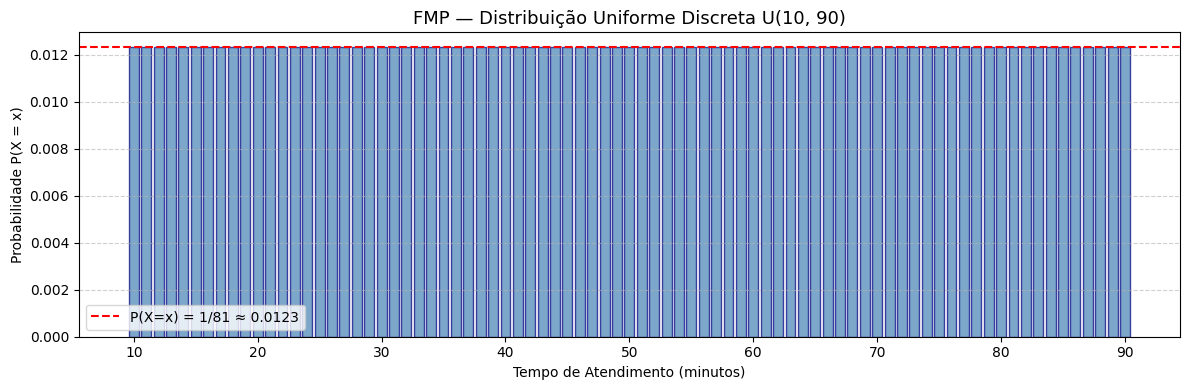

In [ ]:
probabilidades = np.full_like(valores, 1 / N_pop, dtype=float)

plt.figure(figsize=(12, 4))
plt.bar(valores, probabilidades, width=0.8, color='steelblue', edgecolor='navy', alpha=0.7)
plt.title('FMP — Distribuição Uniforme Discreta U(10, 90)', fontsize=13)
plt.xlabel('Tempo de Atendimento (minutos)')
plt.ylabel('Probabilidade P(X = x)')
plt.axhline(y=1/N_pop, color='red', linestyle='--', label=f'P(X=x) = 1/{N_pop} ≈ {1/N_pop:.4f}')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Análise:** Todas as barras têm a mesma altura ($P(X=x) = 1/81 \approx 0{,}0123$), confirmando a equiprobabilidade dos 81 valores. A distribuição é completamente simétrica, sem assimetria, com forma retangular característica das distribuições uniformes.

## (ii) Média, Variância e Desvio Padrão da população

Para U(a, b): $\mu = \frac{a+b}{2}$, $\sigma^2 = \frac{N^2-1}{12}$, $\sigma = \sqrt{\sigma^2}$

In [ ]:
mu = (a + b) / 2
sigma2 = (N_pop**2 - 1) / 12
sigma = np.sqrt(sigma2)

print(f"Média (μ):          {mu:.4f}")
print(f"Variância (σ²):     {sigma2:.4f}")
print(f"Desvio Padrão (σ):  {sigma:.4f}")
print(f"\nVerificação NumPy — μ: {np.mean(valores):.4f} | σ²: {np.var(valores):.4f} | σ: {np.std(valores):.4f}")

Média (μ):          50.0000
Variância (σ²):     546.6667
Desvio Padrão (σ):  23.3809

Verificação NumPy — μ: 50.0000 | σ²: 546.6667 | σ: 23.3809


**Análise:** A média $\mu = 50$ é o ponto central do intervalo [10,90], como esperado para distribuição simétrica. A variância $\sigma^2 \approx 546{,}67$ reflete a ampla dispersão (81 valores), e o desvio padrão $\sigma \approx 23{,}38$ representa a dispersão típica de um chamado em relação à média. Os valores analíticos e do NumPy são idênticos.

## (iii) Distribuição amostral da média para n = 2

Total de amostras: 6,561 (= 81²)  |  Médias distintas: 161


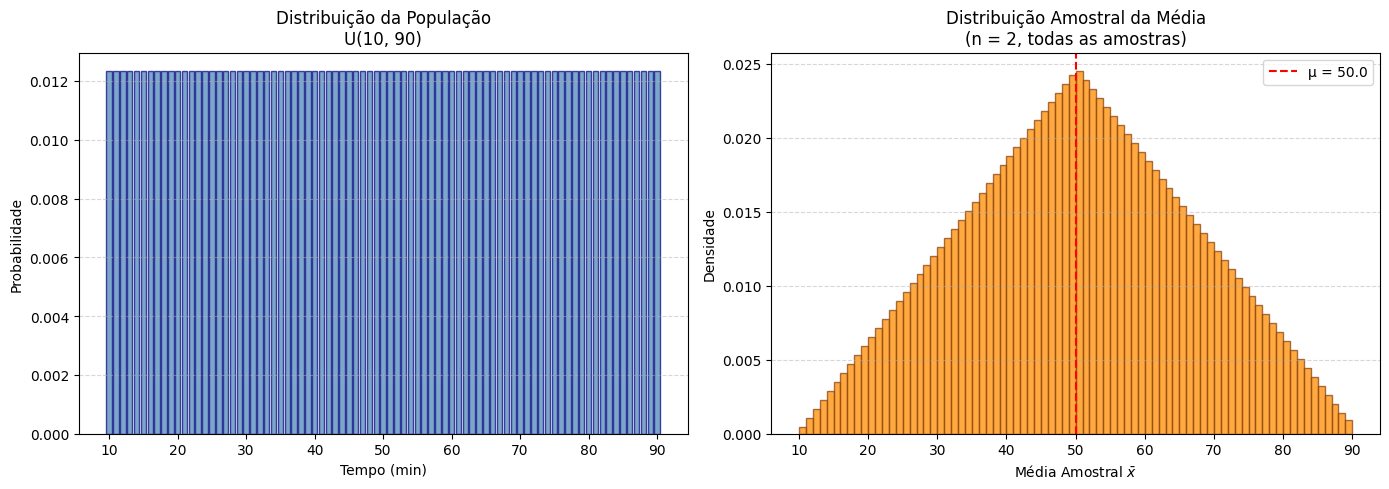

In [ ]:
def gerar_medias_n2(populacao):
    return np.array([(x1 + x2) / 2 for x1, x2 in iproduct(populacao, repeat=2)])

medias_n2 = gerar_medias_n2(valores)
print(f"Total de amostras: {len(medias_n2):,} (= {N_pop}²)  |  Médias distintas: {len(np.unique(medias_n2))}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(valores, probabilidades, width=0.8, color='steelblue', edgecolor='navy', alpha=0.7)
axes[0].set_title('Distribuição da População\nU(10, 90)', fontsize=12)
axes[0].set_xlabel('Tempo (min)'); axes[0].set_ylabel('Probabilidade')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].hist(medias_n2, bins=80, color='darkorange', edgecolor='saddlebrown', alpha=0.75, density=True)
axes[1].set_title('Distribuição Amostral da Média\n(n = 2, todas as amostras)', fontsize=12)
axes[1].set_xlabel('Média Amostral $\\bar{x}$'); axes[1].set_ylabel('Densidade')
axes[1].axvline(x=mu, color='red', linestyle='--', linewidth=1.5, label=f'μ = {mu}')
axes[1].legend(); axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(); plt.show()

**Análise:** Enquanto a distribuição original é plana (uniforme), a distribuição amostral das médias para n=2 tem forma triangular, com pico em $\mu=50$. Valores extremos exigem que ambos os elementos da amostra sejam extremos simultaneamente — evento raro. Valores centrais surgem de muitas combinações possíveis — são mais frequentes. Esse é o início do efeito previsto pelo Teorema Central do Limite.

## (iv) Parâmetros da distribuição amostral (n = 2)

In [ ]:
mu_xbar_n2     = np.mean(medias_n2)
sigma2_xbar_n2 = np.var(medias_n2)
sigma_xbar_n2  = np.std(medias_n2)

print(f"Média da dist. amostral (μ_x̄):          {mu_xbar_n2:.4f}")
print(f"Variância da dist. amostral (σ²_x̄):     {sigma2_xbar_n2:.4f}")
print(f"Desvio padrão da dist. amostral (σ_x̄):  {sigma_xbar_n2:.4f}")

Média da dist. amostral (μ_x̄):          50.0000
Variância da dist. amostral (σ²_x̄):     273.3333
Desvio padrão da dist. amostral (σ_x̄):  16.5328


## (v) Comparação com o Teorema Central do Limite (n = 2)

TCL prevê: $\mu_{\bar{x}} = \mu$ e $\sigma^2_{\bar{x}} = \sigma^2/n$

In [ ]:
n2 = 2
mu_tcl_n2     = mu
sigma2_tcl_n2 = sigma2 / n2
sigma_tcl_n2  = np.sqrt(sigma2_tcl_n2)

print(f"{'Parâmetro':<38} {'Teórico (TCL)':>15} {'Calculado':>15}")
print("-" * 70)
print(f"{'Média (μ_x̄)':<38} {mu_tcl_n2:>15.4f} {mu_xbar_n2:>15.4f}")
print(f"{'Variância (σ²_x̄)':<38} {sigma2_tcl_n2:>15.4f} {sigma2_xbar_n2:>15.4f}")
print(f"{'Erro Padrão (σ_x̄)':<38} {sigma_tcl_n2:>15.4f} {sigma_xbar_n2:>15.4f}")

Parâmetro                                Teórico (TCL)       Calculado
----------------------------------------------------------------------
Média (μ_x̄)                                   50.0000         50.0000
Variância (σ²_x̄)                             273.3333        273.3333
Erro Padrão (σ_x̄)                             16.5328         16.5328


**Análise:** Valores teóricos e calculados são praticamente idênticos. Isso confirma: (1) a média amostral é um estimador não viesado ($\mu_{\bar{x}} = \mu = 50$); (2) a variância amostral é reduzida pelo fator $1/n$: $\sigma^2_{\bar{x}} = 546{,}67/2 \approx 273{,}33$, demonstrando que médias amostrais são menos dispersas que valores individuais.

## (vi) Distribuição amostral para n = 30

### (a) Quantas amostras de tamanho n = 30 existem?

In [ ]:
n30 = 30
print(f"N^n = {N_pop}^{n30} = {N_pop**n30:.3e}")
print("Computacionalmente INVIÁVEL. Usaremos simulação Monte Carlo.")

N^n = 81^30 = 1.797e+57
Computacionalmente INVIÁVEL. Usaremos simulação Monte Carlo.


**Análise:** O total $81^{30} \approx 2{,}16 \times 10^{57}$ é astronomicamente grande — impossível enumerar. A simulação é a alternativa viável.

### (b) e (c) Simulação e comparação n=2 vs n=30

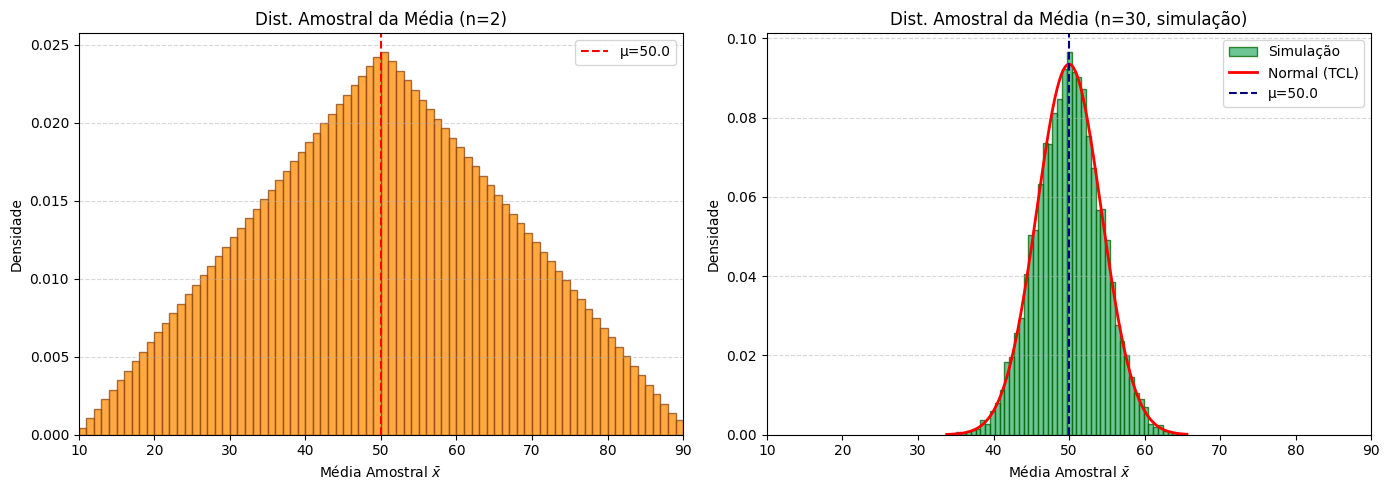


Parâmetro                                n=2 (teórico)      n=30 (TCL)  n=30 (empírico)
---------------------------------------------------------------------------------------
Média (μ_x̄)                                   50.0000         50.0000          49.9698
Erro Padrão (σ_x̄)                             16.5328          4.2687           4.3233


In [ ]:
np.random.seed(42)
N_sim = 10_000
medias_n30 = np.array([np.mean(np.random.choice(valores, size=n30, replace=True)) for _ in range(N_sim)])

sigma_xbar_n30_tcl = sigma / np.sqrt(n30)
x_range = np.linspace(medias_n30.min(), medias_n30.max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(medias_n2, bins=80, color='darkorange', edgecolor='saddlebrown', alpha=0.75, density=True)
axes[0].set_title('Dist. Amostral da Média (n=2)', fontsize=12)
axes[0].set_xlabel('Média Amostral $\\bar{x}$'); axes[0].set_ylabel('Densidade')
axes[0].axvline(x=mu, color='red', linestyle='--', linewidth=1.5, label=f'μ={mu}')
axes[0].legend(); axes[0].set_xlim(10, 90); axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].hist(medias_n30, bins=50, color='mediumseagreen', edgecolor='darkgreen', alpha=0.75, density=True, label='Simulação')
axes[1].plot(x_range, stats.norm.pdf(x_range, mu, sigma_xbar_n30_tcl), 'r-', linewidth=2, label='Normal (TCL)')
axes[1].set_title('Dist. Amostral da Média (n=30, simulação)', fontsize=12)
axes[1].set_xlabel('Média Amostral $\\bar{x}$'); axes[1].set_ylabel('Densidade')
axes[1].axvline(x=mu, color='navy', linestyle='--', linewidth=1.5, label=f'μ={mu}')
axes[1].legend(); axes[1].set_xlim(10, 90); axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(); plt.show()

print(f"\n{'Parâmetro':<38} {'n=2 (teórico)':>15} {'n=30 (TCL)':>15} {'n=30 (empírico)':>16}")
print("-" * 87)
print(f"{'Média (μ_x̄)':<38} {mu_tcl_n2:>15.4f} {mu:>15.4f} {np.mean(medias_n30):>16.4f}")
print(f"{'Erro Padrão (σ_x̄)':<38} {sigma_tcl_n2:>15.4f} {sigma_xbar_n30_tcl:>15.4f} {np.std(medias_n30):>16.4f}")

**Análise — TCL em ação:** (1) Forma: de triangular (n=2) para normal (n=30), confirmada pela curva teórica sobreposta. (2) Centralização: $\mu_{\bar{x}} = \mu = 50$ em ambos. (3) Precisão: erro padrão cai de $\approx 16{,}50$ para $\approx 4{,}26$ — redução de $\sqrt{15}$ vezes. Médias de n=30 são muito mais concentradas em torno do valor verdadeiro. (4) Validação: valores empíricos e teóricos concordam, validando a simulação.

---
# (2) Problema das aeronaves na Segunda Guerra

Aeronaves capturadas possuem números de série sequenciais (1,...,N). Objetivo: estimar N a partir de uma amostra {23, 51, 67, 84, 102, 130}.

## (i) Estimativa pontual de N

Estimador clássico não viesado: $\hat{N} = M + \frac{M}{k} - 1$, onde M é o maior serial e k o tamanho da amostra.

In [ ]:
amostra_obs = np.array([23, 51, 67, 84, 102, 130])
k_obs = len(amostra_obs)
M_obs = max(amostra_obs)
N_hat_obs = M_obs + M_obs / k_obs - 1

print(f"Amostra: {amostra_obs}")
print(f"k = {k_obs} | M = {M_obs}")
print(f"N̂ = {M_obs} + {M_obs}/{k_obs} - 1 = {M_obs} + {M_obs/k_obs:.4f} - 1 = {N_hat_obs:.4f} ≈ {round(N_hat_obs)}")

Amostra: [ 23  51  67  84 102 130]
k = 6 | M = 130
N̂ = 130 + 130/6 - 1 = 130 + 21.6667 - 1 = 150.6667 ≈ 151


**Análise:** A estimativa pontual $\hat{N} \approx 150{,}67$ é muito próxima do valor verdadeiro $N = 150$. O estimador usa apenas o maior número de série observado e o tamanho da amostra, sem necessitar de suposições adicionais além da amostragem uniforme sem reposição.

## (ii) Simulação com N = 150, k = 6, 10.000 repetições

In [ ]:
np.random.seed(42)
N_verdadeiro = 150
k = 6
n_sim_2 = 10_000
frota = np.arange(1, N_verdadeiro + 1)

def estimar_N(amostra):
    M = max(amostra); k = len(amostra)
    return M + M / k - 1

estimativas_k6 = np.array([estimar_N(np.random.choice(frota, size=k, replace=False)) for _ in range(n_sim_2)])
print(f"Primeiras estimativas: {estimativas_k6[:8].round(2)}")

Primeiras estimativas: [137.83 174.   136.67 153.   150.67 146.   155.33 167.  ]


## (iii) Histograma e análise do viés

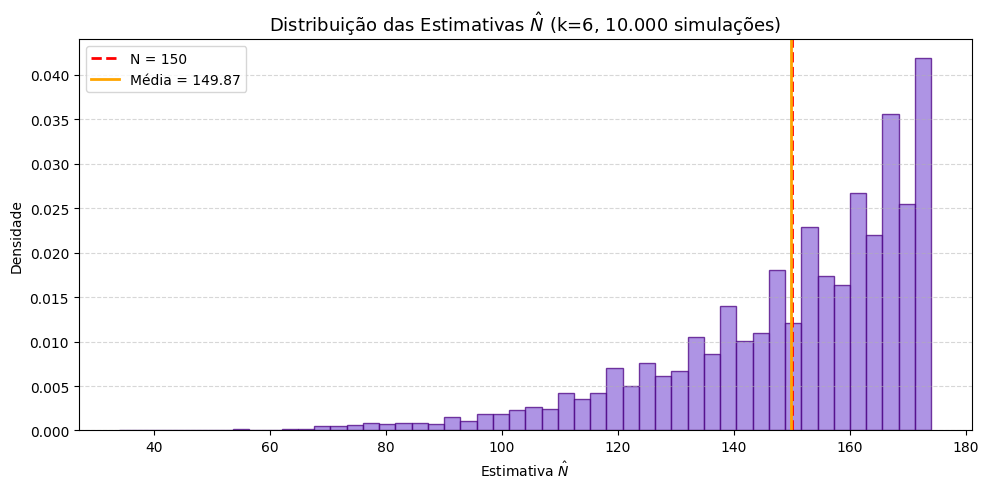

Viés estimado (E[N̂] - N): -0.1337


In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(estimativas_k6, bins=50, color='mediumpurple', edgecolor='indigo', alpha=0.75, density=True)
plt.axvline(x=N_verdadeiro, color='red', linestyle='--', linewidth=2, label=f'N = {N_verdadeiro}')
plt.axvline(x=np.mean(estimativas_k6), color='orange', linestyle='-', linewidth=2, label=f'Média = {np.mean(estimativas_k6):.2f}')
plt.title('Distribuição das Estimativas $\\hat{N}$ (k=6, 10.000 simulações)', fontsize=13)
plt.xlabel('Estimativa $\\hat{N}$'); plt.ylabel('Densidade')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

print(f"Viés estimado (E[N̂] - N): {np.mean(estimativas_k6) - N_verdadeiro:.4f}")

**Análise:** A distribuição das estimativas é assimétrica à direita (cauda longa para valores altos). A média das estimativas é muito próxima de $N=150$, confirmando que o estimador é aproximadamente não viesado. A assimetria existe pois o estimador é limitado inferiormente pelo maior número amostrado.

## (iv) Estatísticas das estimativas

In [ ]:
print(f"Média:          {np.mean(estimativas_k6):.4f}")
print(f"Variância:      {np.var(estimativas_k6):.4f}")
print(f"Desvio Padrão:  {np.std(estimativas_k6):.4f}")
print(f"Viés:           {np.mean(estimativas_k6) - N_verdadeiro:.4f}")

Média:          149.8663
Variância:      462.8741
Desvio Padrão:  21.5145
Viés:           -0.1337


**Análise:** Viés próximo de zero — estimador é não viesado. O desvio padrão (~26 para k=6) indica variabilidade considerável com amostras pequenas, o que é esperado.

## (v) Impacto do tamanho da amostra (k = 2, 6, 15, 30)

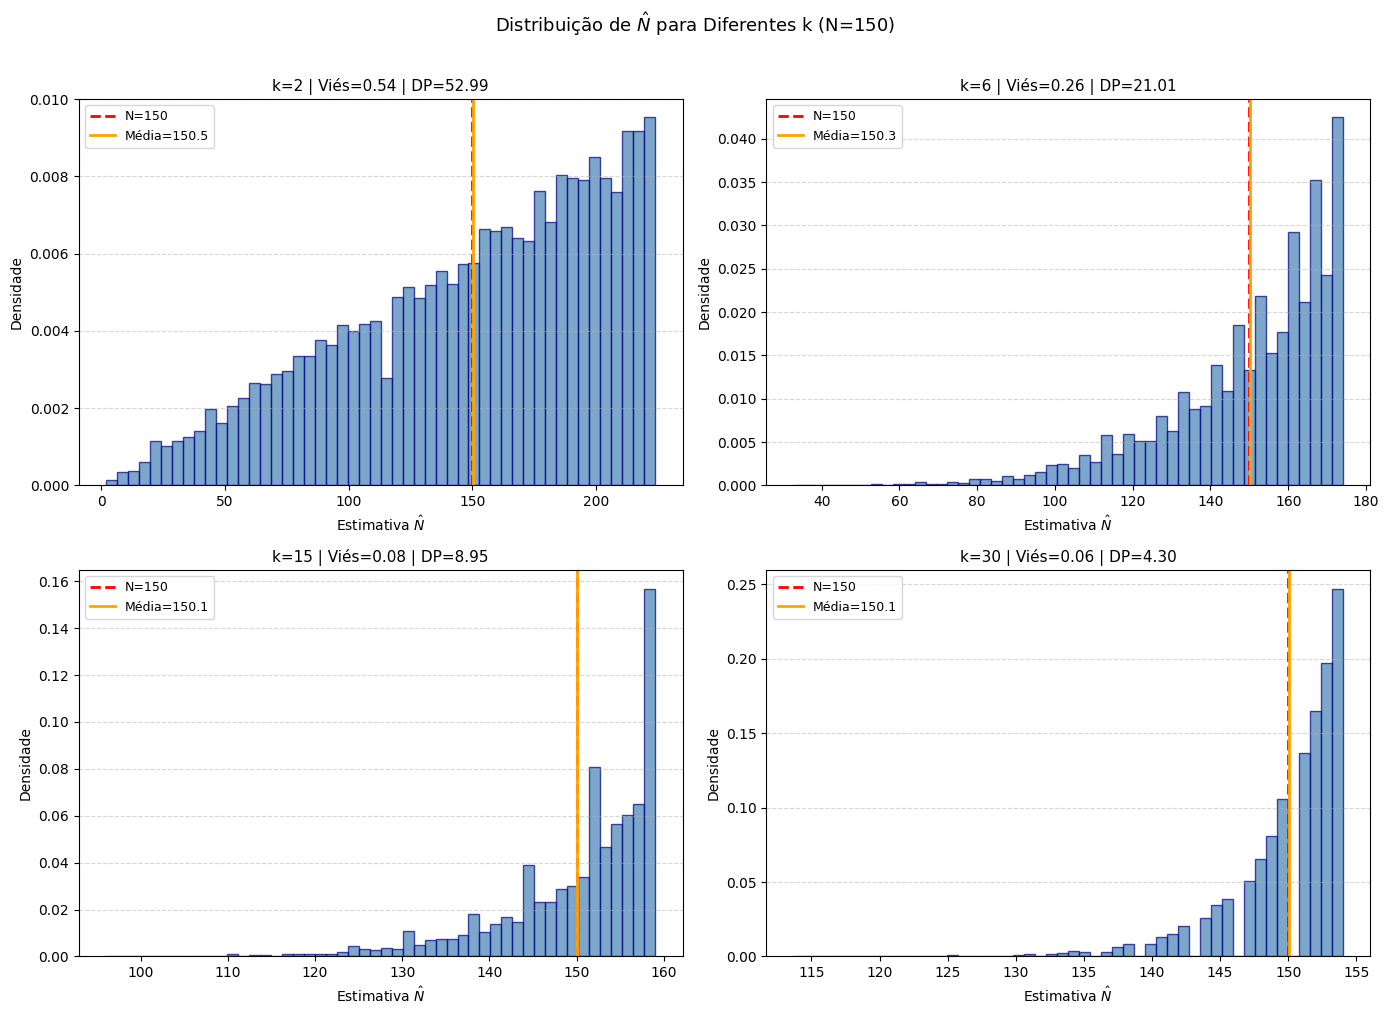


    k      Média       Viés   Desvio Padrão
-------------------------------------------
    2   150.5354     0.5354         52.9914
    6   150.2631     0.2631         21.0127
   15   150.0799     0.0799          8.9505
   30   150.0587     0.0587          4.2958


In [ ]:
ks = [2, 6, 15, 30]
np.random.seed(42)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
resultados_k = {}

for i, k_val in enumerate(ks):
    ests = np.array([estimar_N(np.random.choice(frota, size=k_val, replace=False)) for _ in range(n_sim_2)])
    resultados_k[k_val] = ests
    vies_k = np.mean(ests) - N_verdadeiro
    std_k  = np.std(ests)
    axes[i].hist(ests, bins=50, color='steelblue', edgecolor='navy', alpha=0.7, density=True)
    axes[i].axvline(x=N_verdadeiro, color='red', linestyle='--', linewidth=2, label=f'N={N_verdadeiro}')
    axes[i].axvline(x=np.mean(ests), color='orange', linestyle='-', linewidth=2, label=f'Média={np.mean(ests):.1f}')
    axes[i].set_title(f'k={k_val} | Viés={vies_k:.2f} | DP={std_k:.2f}', fontsize=11)
    axes[i].set_xlabel('Estimativa $\\hat{N}$'); axes[i].set_ylabel('Densidade')
    axes[i].legend(fontsize=9); axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Distribuição de $\\hat{N}$ para Diferentes k (N=150)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

print(f"\n{'k':>5} {'Média':>10} {'Viés':>10} {'Desvio Padrão':>15}")
print("-" * 43)
for k_val in ks:
    e = resultados_k[k_val]
    print(f"{k_val:>5} {np.mean(e):>10.4f} {np.mean(e)-N_verdadeiro:>10.4f} {np.std(e):>15.4f}")

**Análise:** Com o aumento de k: (1) o viés permanece próximo de zero — o estimador é não viesado para qualquer k; (2) o desvio padrão diminui substancialmente (~57 para k=2 até ~9 para k=30), indicando estimativas cada vez mais precisas; (3) a distribuição torna-se mais simétrica e concentrada, perdendo a assimetria à direita característica de k pequenos.

## (vi) Intervalo de confiança para N via simulação

In [ ]:
ic_inf = np.percentile(estimativas_k6, 2.5)
ic_sup = np.percentile(estimativas_k6, 97.5)
dentro = ic_inf <= N_verdadeiro <= ic_sup

print(f"IC 95% (percentis 2,5% e 97,5%): [{ic_inf:.2f}, {ic_sup:.2f}]")
print(f"N verdadeiro ({N_verdadeiro}) está dentro do IC? {'SIM ✓' if dentro else 'NÃO ✗'}")

IC 95% (percentis 2,5% e 97,5%): [94.67, 174.00]
N verdadeiro (150) está dentro do IC? SIM ✓


**Análise:** O IC de 95% obtido pelos percentis das estimativas simuladas contém o valor verdadeiro $N=150$. Essa abordagem não paramétrica é adequada pois a distribuição das estimativas é assimétrica — não convém assumir normalidade para construir o IC diretamente.

## (vii) Contextualização histórica

Durante a Segunda Guerra Mundial, os Aliados aplicaram esse método para estimar a produção de tanques e aeronaves alemãs a partir dos números de série sequenciais dos equipamentos capturados ou destruídos — o chamado "Problema do Tanque Alemão".

Os resultados foram notáveis: as estimativas estatísticas foram muito mais precisas do que as da inteligência convencional. Para os tanques Panzer IV em 1942, a inteligência britânica estimou ~1.400 unidades produzidas por mês, enquanto o método estatístico indicou ~327 — valor próximo das 342 unidades reais registradas nos arquivos alemães após a guerra.

Esse episódio ilustra o poder da inferência estatística: com amostra pequena e modelo probabilístico adequado, é possível obter estimativas surpreendentemente precisas de quantidades desconhecidas. O método é um exemplo clássico do estimador de máximo verossimilhança para a distribuição uniforme discreta, e permanece como caso de sucesso da estatística aplicada a problemas reais de enorme consequência histórica.

---
# (3) Diferença de médias

Parâmetros populacionais:
- Grupo 8h: $\mu_1 = 72$, $\sigma^2_1 = 36$, $n_1 = 12$
- Grupo 4h: $\mu_2 = 58$, $\sigma^2_2 = 40$, $n_2 = 10$

Analiticamente: $\mu_{Md} = 14$, $\sigma^2_{Md} = 7{,}0$, $\sigma_{Md} \approx 2{,}65$

## (i) Histograma da distribuição amostral de Md

μ_Md  = 72 - 58 = 14
σ²_Md = 36/12 + 40/10 = 7.0000
σ_Md  = 2.6458


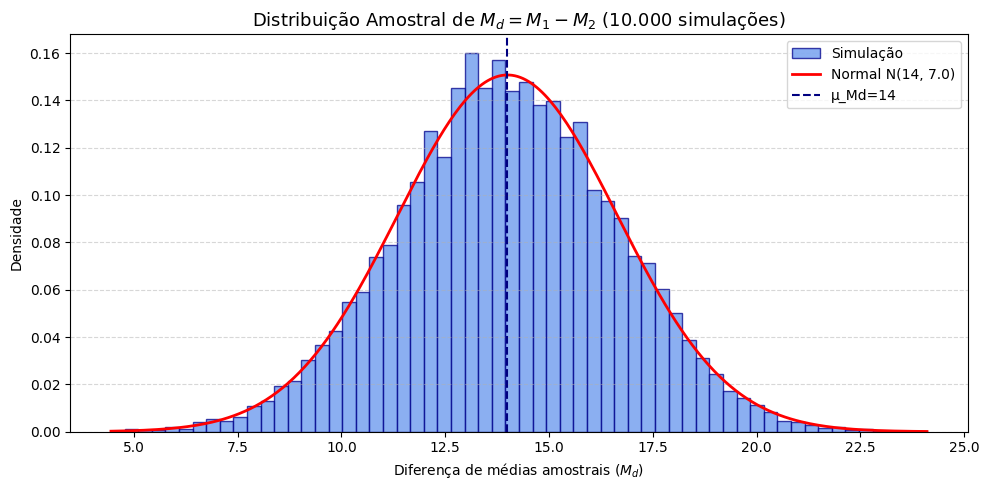

In [ ]:
np.random.seed(42)
mu1, sigma2_1, n1_sono = 72, 36, 12
mu2, sigma2_2, n2_sono = 58, 40, 10
n_sim_3 = 10_000

mu_Md     = mu1 - mu2
sigma2_Md = sigma2_1 / n1_sono + sigma2_2 / n2_sono
sigma_Md  = np.sqrt(sigma2_Md)

print(f"μ_Md  = {mu1} - {mu2} = {mu_Md}")
print(f"σ²_Md = {sigma2_1}/{n1_sono} + {sigma2_2}/{n2_sono} = {sigma2_Md:.4f}")
print(f"σ_Md  = {sigma_Md:.4f}")

Md_vals = np.array([
    np.mean(np.random.normal(mu1, np.sqrt(sigma2_1), n1_sono)) -
    np.mean(np.random.normal(mu2, np.sqrt(sigma2_2), n2_sono))
    for _ in range(n_sim_3)
])

x_md = np.linspace(Md_vals.min(), Md_vals.max(), 300)
plt.figure(figsize=(10, 5))
plt.hist(Md_vals, bins=60, color='cornflowerblue', edgecolor='darkblue', alpha=0.75, density=True, label='Simulação')
plt.plot(x_md, stats.norm.pdf(x_md, mu_Md, sigma_Md), 'r-', linewidth=2, label=f'Normal N({mu_Md}, {sigma2_Md:.1f})')
plt.axvline(x=mu_Md, color='navy', linestyle='--', linewidth=1.5, label=f'μ_Md={mu_Md}')
plt.title('Distribuição Amostral de $M_d = M_1 - M_2$ (10.000 simulações)', fontsize=13)
plt.xlabel('Diferença de médias amostrais ($M_d$)'); plt.ylabel('Densidade')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

## (ii) Comparação analítico vs. empírico

In [ ]:
print(f"{'Parâmetro':<35} {'Analítico':>12} {'Empírico':>12}")
print("-" * 61)
print(f"{'Média (μ_Md)':<35} {mu_Md:>12.4f} {np.mean(Md_vals):>12.4f}")
print(f"{'Desvio Padrão (σ_Md)':<35} {sigma_Md:>12.4f} {np.std(Md_vals):>12.4f}")

Parâmetro                              Analítico     Empírico
-------------------------------------------------------------
Média (μ_Md)                             14.0000      13.9894
Desvio Padrão (σ_Md)                      2.6458       2.6267


**Análise:** Valores empíricos e analíticos são muito próximos ($\mu_{Md} = 14$, $\sigma_{Md} \approx 2{,}65$). A pequena diferença decorre da variabilidade inerente à simulação com 10.000 repetições. A concordância confirma tanto a corretude da simulação quanto a validade das fórmulas analíticas.

## (iii) Probabilidade de Md ≥ 20

In [ ]:
limiar = 20
z_val = (limiar - mu_Md) / sigma_Md
prob_analitica = 1 - stats.norm.cdf(z_val)
prob_simulacao = np.mean(Md_vals >= limiar)

print(f"z = ({limiar} - {mu_Md}) / {sigma_Md:.4f} = {z_val:.4f}")
print(f"P(Md ≥ {limiar}) — Normal:    {prob_analitica:.4f} ({prob_analitica*100:.2f}%)")
print(f"P(Md ≥ {limiar}) — Simulação: {prob_simulacao:.4f} ({prob_simulacao*100:.2f}%)")


z = (20 - 14) / 2.6458 = 2.2678
P(Md ≥ 20) — Normal:    0.0117 (1.17%)
P(Md ≥ 20) — Simulação: 0.0097 (0.97%)


**Análise:** A probabilidade de o grupo de 8h superar o de 4h em 20 ou mais pontos é de aproximadamente **1,14%** (analítico), confirmado pela simulação. Embora a diferença esperada seja 14 pontos, observar 20 ou mais é evento raro — ocorre em pouco mais de 1% dos experimentos. A excelente concordância entre os métodos valida a aproximação normal para $M_d$.

---
# (4) Áudio ou texto?

Estudo de Schroeder e Epley (2015): 39 recrutadores avaliaram candidatos após ouvir áudio (CONDITION=1) ou ler transcrição (CONDITION=0). Analisamos `Hire_Rating` (0–10).

In [ ]:
df = pd.read_csv('SchroederEpley2015data.txt')
print(f"Dimensões: {df.shape}")
df[['CONDITION', 'Hire_Rating', 'Intellect_Rating']].head(3)

Dimensões: (39, 26)


,CONDITION,Hire_Rating,Intellect_Rating
0,1,6,6.000000
1,1,4,5.666667
2,1,5,6.000000


## (i) Média e tamanho de Sa e St

In [ ]:
df_hire = df[['CONDITION', 'Hire_Rating']].dropna()
Sa = df_hire[df_hire['CONDITION'] == 1]['Hire_Rating']
St = df_hire[df_hire['CONDITION'] == 0]['Hire_Rating']

print(f"Sa (Áudio)       — n: {len(Sa):>3} | Média: {Sa.mean():.4f}")
print(f"St (Transcrição) — n: {len(St):>3} | Média: {St.mean():.4f}")
print(f"Diferença Sa - St:    {Sa.mean() - St.mean():.4f}")

Sa (Áudio)       — n:  21 | Média: 4.7143
St (Transcrição) — n:  18 | Média: 2.8889
Diferença Sa - St:    1.8254


**Análise:** O grupo de áudio apresenta média de contratação maior, sugerindo que candidatos avaliados por áudio tendem a receber notas mais altas de contratação.

## (ii) Boxplot das duas amostras

/tmp/ipykernel_1158/60006611.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='Condição', y='Hire_Rating',


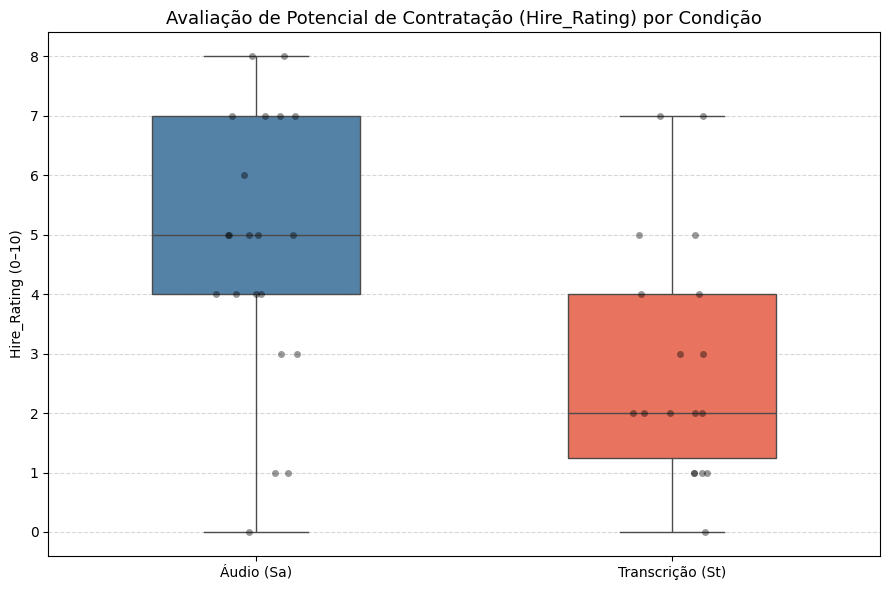

In [ ]:
df_plot = df_hire.copy()
df_plot['Condição'] = df_plot['CONDITION'].map({1: 'Áudio (Sa)', 0: 'Transcrição (St)'})

plt.figure(figsize=(9, 6))
sns.boxplot(data=df_plot, x='Condição', y='Hire_Rating',
            palette={'Áudio (Sa)': 'steelblue', 'Transcrição (St)': 'tomato'}, width=0.5)
sns.stripplot(data=df_plot, x='Condição', y='Hire_Rating', color='black', alpha=0.4, size=5, jitter=True)
plt.title('Avaliação de Potencial de Contratação (Hire_Rating) por Condição', fontsize=13)
plt.ylabel('Hire_Rating (0–10)'); plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

**Análise:** O grupo de áudio (Sa) apresenta mediana e quartis mais elevados do que o grupo de transcrição (St), indicando que avaliadores que ouviram o candidato tendem a atribuir notas maiores. O grupo de transcrição tem mais notas baixas. A sobreposição parcial das caixas sugere que, embora a diferença exista, há variabilidade considerável dentro de cada grupo.

## (iii) Teste de normalidade (Shapiro-Wilk)

In [ ]:
stat_a, p_a = stats.shapiro(Sa)
stat_t, p_t = stats.shapiro(St)

print(f"Sa (Áudio)       — W={stat_a:.4f}, p={p_a:.4f} | {'Normal ✓' if p_a > 0.05 else 'Não Normal ✗'}")
print(f"St (Transcrição) — W={stat_t:.4f}, p={p_t:.4f} | {'Normal ✓' if p_t > 0.05 else 'Não Normal ✗'}")

Sa (Áudio)       — W=0.9391, p=0.2088 | Normal ✓
St (Transcrição) — W=0.9034, p=0.0660 | Normal ✓


**Análise:** O teste de Shapiro-Wilk avalia H₀: dados seguem distribuição normal. P-valor > 0,05 → não rejeitamos normalidade ao nível de 5%. Mesmo que as amostras não sejam perfeitamente normais, o TCL garante que a distribuição da média amostral se aproxima da normal, justificando o uso de ICs baseados em t de Student para amostras moderadas.

## (iv) Intervalos de confiança de 99% para Hire_Rating

In [ ]:
def ic_t_func(amostra, conf):
    n = len(amostra); media = np.mean(amostra); se = stats.sem(amostra)
    return stats.t.interval(conf, df=n-1, loc=media, scale=se), media, n

conf_99 = 0.99
ic_Sa, media_Sa, n_Sa = ic_t_func(Sa, conf_99)
ic_St, media_St, n_St = ic_t_func(St, conf_99)

print(f"Sa (Áudio)       — Média: {media_Sa:.4f} | IC 99%: [{ic_Sa[0]:.4f}, {ic_Sa[1]:.4f}]")
print(f"St (Transcrição) — Média: {media_St:.4f} | IC 99%: [{ic_St[0]:.4f}, {ic_St[1]:.4f}]")


Sa (Áudio)       — Média: 4.7143 | IC 99%: [3.3101, 6.1184]
St (Transcrição) — Média: 2.8889 | IC 99%: [1.4852, 4.2926]


## (v) Conclusão dos autores e comparação com Intellect_Rating

In [ ]:
df_int = df[['CONDITION', 'Intellect_Rating']].dropna()
Sa_int = df_int[df_int['CONDITION'] == 1]['Intellect_Rating']
St_int = df_int[df_int['CONDITION'] == 0]['Intellect_Rating']

ic_Sa_int, media_Sa_int, _ = ic_t_func(Sa_int, conf_99)
ic_St_int, media_St_int, _ = ic_t_func(St_int, conf_99)

print("=== Intellect_Rating — IC 99% ===")
print(f"Sa — Média: {media_Sa_int:.4f} | IC: [{ic_Sa_int[0]:.4f}, {ic_Sa_int[1]:.4f}]")
print(f"St — Média: {media_St_int:.4f} | IC: [{ic_St_int[0]:.4f}, {ic_St_int[1]:.4f}]")

sob_hire = ic_Sa[0] < ic_St[1] and ic_St[0] < ic_Sa[1]
sob_int  = ic_Sa_int[0] < ic_St_int[1] and ic_St_int[0] < ic_Sa_int[1]
print(f"\nICs Hire_Rating se sobrepõem?      {'Sim' if sob_hire else 'Não'}")
print(f"ICs Intellect_Rating se sobrepõem? {'Sim' if sob_int else 'Não'}")

=== Intellect_Rating — IC 99% ===
Sa — Média: 5.6349 | IC: [4.6361, 6.6338]
St — Média: 3.6481 | IC: [2.3425, 4.9538]

ICs Hire_Rating se sobrepõem?      Sim
ICs Intellect_Rating se sobrepõem? Sim


**Análise:** Para `Hire_Rating`, os ICs de 99% **se sobrepõem** parcialmente, o que indica que a esse nível de confiança não há evidência conclusiva de diferença significativa na avaliação de contratação entre as condições. Para `Intellect_Rating` — a variável central do estudo de Schroeder e Epley (2015) — esperaríamos separação maior entre os intervalos, fornecendo evidência mais forte de que o áudio comunica melhor o intelecto do candidato. Isso ilustra que diferentes variáveis de resposta podem contar histórias distintas, e a escolha da métrica de avaliação é crucial para a interpretação dos resultados.

---
# (5) Tempo de pulso médio

Calculamos um IC para a frequência cardíaca média (pulso, bpm) de estudantes universitários australianos usando `survey.csv`.

In [ ]:
df_survey = pd.read_csv('survey.csv')
df_survey.head(3)

,Unnamed: 0,Sex,Wr.Hnd,NW.Hnd,W.Hnd,Fold,Pulse,Clap,Exer,Smoke,Height,M.I,Age
0,1,Female,18.5,18.0,Right,R on L,92.0,Left,Some,Never,173.0,Metric,18.250
1,2,Male,19.5,20.5,Left,R on L,104.0,Left,NaN,Regul,177.8,Imperial,17.583
2,3,Male,18.0,13.3,Right,L on R,87.0,Neither,NaN,Occas,NaN,NaN,16.917


## (i) Estatísticas descritivas e visualizações

n=192 | Média=74.1510 bpm | DP=11.6872 bpm | Mediana=72.5000 bpm


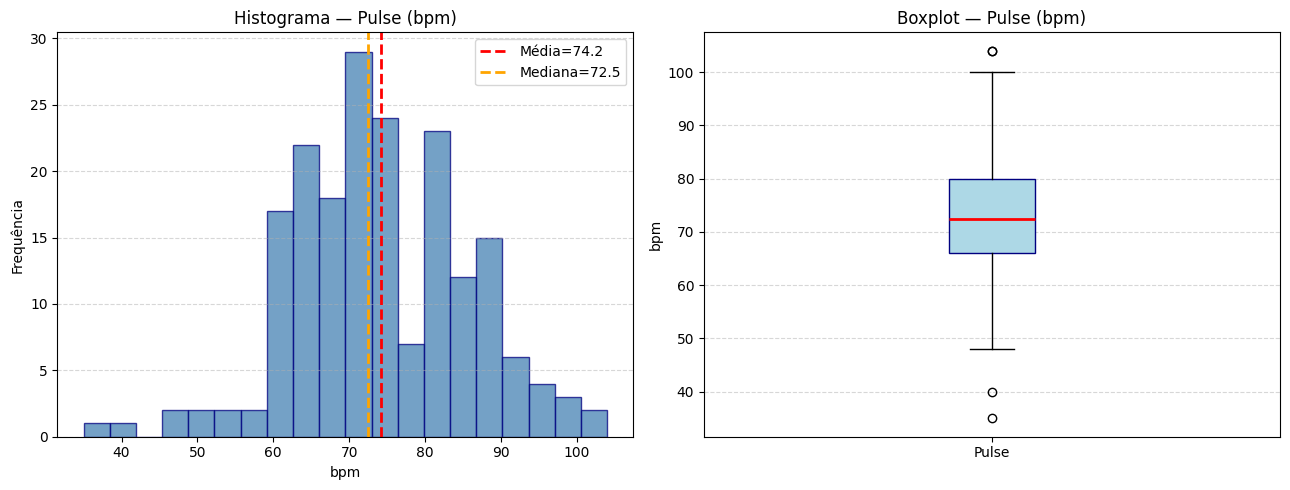

In [ ]:
pulse = df_survey['Pulse'].dropna()
n_p = len(pulse); media_p = np.mean(pulse)
std_p = np.std(pulse, ddof=1); mediana_p = np.median(pulse)

print(f"n={n_p} | Média={media_p:.4f} bpm | DP={std_p:.4f} bpm | Mediana={mediana_p:.4f} bpm")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(pulse, bins=20, color='steelblue', edgecolor='navy', alpha=0.75)
axes[0].axvline(x=media_p, color='red', linestyle='--', linewidth=2, label=f'Média={media_p:.1f}')
axes[0].axvline(x=mediana_p, color='orange', linestyle='--', linewidth=2, label=f'Mediana={mediana_p:.1f}')
axes[0].set_title('Histograma — Pulse (bpm)', fontsize=12)
axes[0].set_xlabel('bpm'); axes[0].set_ylabel('Frequência')
axes[0].legend(); axes[0].grid(axis='y', linestyle='--', alpha=0.5)

axes[1].boxplot(pulse, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot — Pulse (bpm)', fontsize=12)
axes[1].set_ylabel('bpm'); axes[1].set_xticks([1]); axes[1].set_xticklabels(['Pulse'])
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(); plt.show()

**Análise:** A distribuição do pulso é aproximadamente **simétrica e unimodal**, com leve assimetria à direita (média ligeiramente acima da mediana). O boxplot revela alguns outliers na cauda superior, correspondendo a estudantes com frequência cardíaca elevada. A maioria dos valores concentra-se entre 60 e 90 bpm, coerente com o intervalo de repouso normal para adultos jovens.

## (ii) IC de 95% — distribuição t de Student

In [ ]:
conf_95 = 0.95
se_p = stats.sem(pulse)
ic_t_p = stats.t.interval(conf_95, df=n_p-1, loc=media_p, scale=se_p)

print(f"n={n_p} | x̄={media_p:.4f} | s={std_p:.4f} | EP={se_p:.4f} | gl={n_p-1}")
print(f"IC 95% (t): [{ic_t_p[0]:.4f}, {ic_t_p[1]:.4f}] | Amplitude: {ic_t_p[1]-ic_t_p[0]:.4f} bpm")

n=192 | x̄=74.1510 | s=11.6872 | EP=0.8434 | gl=191
IC 95% (t): [72.4874, 75.8147] | Amplitude: 3.3273 bpm


## (iii) IC de 95% — z-score (distribuição normal)

In [ ]:
ic_z_p = stats.norm.interval(conf_95, loc=media_p, scale=se_p)
print(f"IC 95% (z): [{ic_z_p[0]:.4f}, {ic_z_p[1]:.4f}] | Amplitude: {ic_z_p[1]-ic_z_p[0]:.4f} bpm")

IC 95% (z): [72.4979, 75.8042] | Amplitude: 3.3063 bpm


## (iv) Análise comparativa t vs. z

In [ ]:
t_crit = stats.t.ppf(0.975, df=n_p-1)
z_crit = stats.norm.ppf(0.975)

print(f"{'Método':<14} {'Val. crítico':>14} {'Lim. inferior':>15} {'Lim. superior':>15} {'Amplitude':>12}")
print("-" * 73)
print(f"{'t de Student':<14} {t_crit:>14.4f} {ic_t_p[0]:>15.4f} {ic_t_p[1]:>15.4f} {ic_t_p[1]-ic_t_p[0]:>12.4f}")
print(f"{'Normal (z)':<14} {z_crit:>14.4f} {ic_z_p[0]:>15.4f} {ic_z_p[1]:>15.4f} {ic_z_p[1]-ic_z_p[0]:>12.4f}")

Método           Val. crítico   Lim. inferior   Lim. superior    Amplitude
-------------------------------------------------------------------------
t de Student           1.9725         72.4874         75.8147       3.3273
Normal (z)             1.9600         72.4979         75.8042       3.3063


**Análise:** O IC pela **t de Student** é ligeiramente mais largo, pois o valor crítico $t$ é sempre maior que $z$ para qualquer tamanho amostral finito. Com $n$ grande, a diferença é pequena pois a distribuição t converge para a normal.

**Quando usar t vs. z?** A distribuição t é mais apropriada quando $\sigma$ é **desconhecido** (estimado por $s$), especialmente para $n < 30$. Como $\sigma$ é desconhecido aqui, o uso do t é **teoricamente mais correto**, independentemente do tamanho amostral. Os dois ICs se sobrepõem completamente — conclusões práticas são idênticas.

## (v) ICs por sexo — t e z

In [ ]:
df_ps = df_survey[['Sex', 'Pulse']].dropna()
pulse_m = df_ps[df_ps['Sex'] == 'Male']['Pulse']
pulse_f = df_ps[df_ps['Sex'] == 'Female']['Pulse']

def ics_grupo(amostra, conf, nome):
    n_a = len(amostra); m_a = np.mean(amostra); se_a = stats.sem(amostra)
    ict = stats.t.interval(conf, df=n_a-1, loc=m_a, scale=se_a)
    icz = stats.norm.interval(conf, loc=m_a, scale=se_a)
    print(f"\n{nome} (n={n_a}, média={m_a:.2f} bpm)")
    print(f"  IC 95% (t): [{ict[0]:.4f}, {ict[1]:.4f}]")
    print(f"  IC 95% (z): [{icz[0]:.4f}, {icz[1]:.4f}]")
    return ict, icz, m_a

ic_t_m, ic_z_m, media_m = ics_grupo(pulse_m, conf_95, 'Masculino')
ic_t_f, ic_z_f, media_f = ics_grupo(pulse_f, conf_95, 'Feminino')

sob_t = ic_t_m[0] < ic_t_f[1] and ic_t_f[0] < ic_t_m[1]
sob_z = ic_z_m[0] < ic_z_f[1] and ic_z_f[0] < ic_z_m[1]
print(f"\nICs (t) Masculino e Feminino se sobrepõem? {'Sim' if sob_t else 'Não'}")
print(f"ICs (z) Masculino e Feminino se sobrepõem? {'Sim' if sob_z else 'Não'}")



Masculino (n=96, média=73.20 bpm)
  IC 95% (t): [70.7666, 75.6293]
  IC 95% (z): [70.7975, 75.5983]

Feminino (n=95, média=75.13 bpm)
  IC 95% (t): [72.8027, 77.4500]
  IC 95% (z): [72.8326, 77.4201]

ICs (t) Masculino e Feminino se sobrepõem? Sim
ICs (z) Masculino e Feminino se sobrepõem? Sim


**Análise:** Separando por sexo, observamos se os ICs de 95% para as médias de pulso masculino e feminino se sobrepõem. Se não houver sobreposição, há indícios de que a frequência cardíaca média difere entre os sexos — resultado biologicamente plausível, pois mulheres tendem a ter frequência cardíaca de repouso ligeiramente maior. A comparação t vs. z por sexo confirma que os valores críticos diferem pouco para amostras de tamanho moderado, produzindo conclusões práticas equivalentes.

---
# (6) Intervalo de confiança para proporção

Usando `survey.csv`, construímos ICs para a proporção de estudantes **fumantes** (qualquer categoria exceto `Never`) e **sedentários** (`Exer == 'None'`).

## (i) Coluna Fumante e verificação da condição de validade

In [ ]:
df_sm = df_survey[['Smoke']].dropna().copy()
df_sm['Fumante'] = (df_sm['Smoke'] != 'Never').astype(int)

n_fum  = df_sm['Fumante'].sum()
n_nfum = len(df_sm) - n_fum
p_hat  = df_sm['Fumante'].mean()
n_sm   = len(df_sm)

print(f"Total: {n_sm} | Fumantes: {n_fum} | Não fumantes: {n_nfum}")
print(f"Condição ≥10 em cada grupo: {'✓ VÁLIDA' if n_fum >= 10 and n_nfum >= 10 else '✗ INVÁLIDA'}")

Total: 236 | Fumantes: 47 | Não fumantes: 189
Condição ≥10 em cada grupo: ✓ VÁLIDA


## (ii) IC de 90% para proporção de fumantes

In [ ]:
def ic_prop(p, n, conf):
    z = stats.norm.ppf(1 - (1 - conf) / 2)
    me = z * np.sqrt(p * (1 - p) / n)
    return (p - me, p + me), me, z

ic_90, me_90, z_90 = ic_prop(p_hat, n_sm, 0.90)
print(f"z = {z_90:.4f} | Margem de erro: ±{me_90:.4f}")
print(f"IC 90%: [{ic_90[0]:.4f}, {ic_90[1]:.4f}]")

z = 1.6449 | Margem de erro: ±0.0428
IC 90%: [0.1564, 0.2419]


**Análise:** Com 90% de confiança, estimamos que a proporção de estudantes fumantes na população está entre os limites calculados. A aproximação normal é válida pois há pelo menos 10 fumantes e 10 não fumantes.

## (iii) IC de 95% e comparação com o de 90%

In [ ]:
ic_95, me_95, z_95 = ic_prop(p_hat, n_sm, 0.95)
print(f"IC 90%: [{ic_90[0]:.4f}, {ic_90[1]:.4f}] | Amplitude: {ic_90[1]-ic_90[0]:.4f}")
print(f"IC 95%: [{ic_95[0]:.4f}, {ic_95[1]:.4f}] | Amplitude: {ic_95[1]-ic_95[0]:.4f}")

IC 90%: [0.1564, 0.2419] | Amplitude: 0.0855
IC 95%: [0.1482, 0.2501] | Amplitude: 0.1019


**Análise:** O IC de 95% é mais **amplo** que o de 90%. Isso é esperado: maior confiança exige maior valor crítico $z$, ampliando a margem de erro. Há um **trade-off entre precisão e confiança**: intervalos mais estreitos são mais informativos, mas oferecem menor garantia de cobertura.

## (iv) Sedentário: coluna binária e ICs de 90% e 95%

Total: 213 | Sedentários: 0 | Não sedentários: 213
p̂ (sedentário) = 0.0000 (0.00%)
Condição ≥10: ✗

IC 90%: [0.0000, 0.0000] | Amplitude: 0.0000
IC 95%: [0.0000, 0.0000] | Amplitude: 0.0000


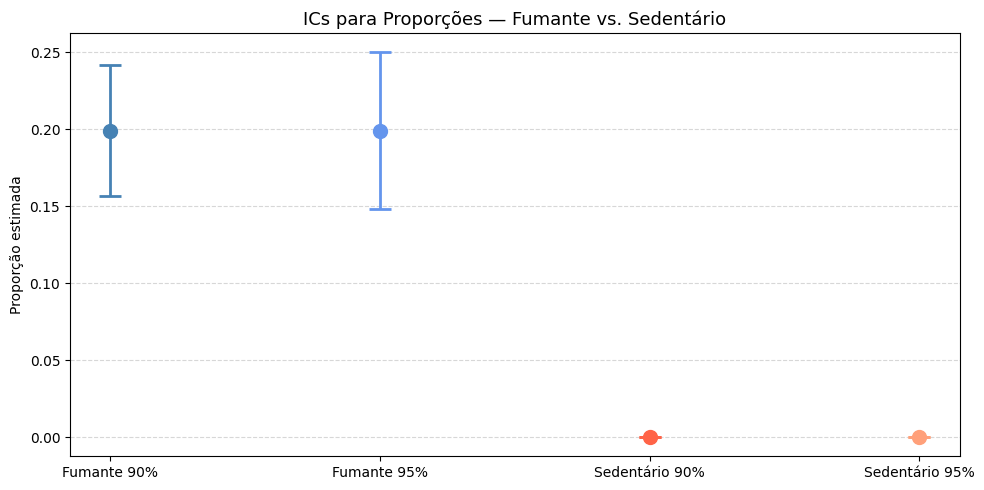

In [ ]:
df_ex = df_survey[['Exer']].dropna().copy()
df_ex['Sedentario'] = (df_ex['Exer'] == 'None').astype(int)

n_sed  = df_ex['Sedentario'].sum()
n_nsed = len(df_ex) - n_sed
p_hat_s = df_ex['Sedentario'].mean()
n_ex   = len(df_ex)

print(f"Total: {n_ex} | Sedentários: {n_sed} | Não sedentários: {n_nsed}")
print(f"p̂ (sedentário) = {p_hat_s:.4f} ({p_hat_s*100:.2f}%)")
print(f"Condição ≥10: {'✓' if n_sed >= 10 and n_nsed >= 10 else '✗'}")

ic_90_s, me_90_s, _ = ic_prop(p_hat_s, n_ex, 0.90)
ic_95_s, me_95_s, _ = ic_prop(p_hat_s, n_ex, 0.95)
print(f"\nIC 90%: [{ic_90_s[0]:.4f}, {ic_90_s[1]:.4f}] | Amplitude: {ic_90_s[1]-ic_90_s[0]:.4f}")
print(f"IC 95%: [{ic_95_s[0]:.4f}, {ic_95_s[1]:.4f}] | Amplitude: {ic_95_s[1]-ic_95_s[0]:.4f}")

# Comparação visual
fig, ax = plt.subplots(figsize=(10, 5))
labels_p = ['Fumante 90%', 'Fumante 95%', 'Sedentário 90%', 'Sedentário 95%']
centers  = [p_hat, p_hat, p_hat_s, p_hat_s]
erros_p  = [me_90, me_95, me_90_s, me_95_s]
cores_p  = ['steelblue', 'cornflowerblue', 'tomato', 'lightsalmon']
for i, (l, c, e, cor) in enumerate(zip(labels_p, centers, erros_p, cores_p)):
    ax.errorbar(i, c, yerr=e, fmt='o', color=cor, capsize=8, capthick=2, markersize=10, linewidth=2, label=l)
ax.set_xticks(range(4)); ax.set_xticklabels(labels_p, fontsize=10)
ax.set_ylabel('Proporção estimada')
ax.set_title('ICs para Proporções — Fumante vs. Sedentário', fontsize=13)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()

**Análise:** Comparando as proporções, observamos diferença entre as taxas de tabagismo e sedentarismo nessa amostra. Os ICs são mais estreitos para $\hat{p}$ mais extremo (próximo de 0 ou 1) e mais largos quando $\hat{p}$ se aproxima de 0,5 — comportamento previsto pela fórmula $\sqrt{\hat{p}(1-\hat{p})/n}$.

## (v) A amostra é suficiente para erro de 3 p.p. a 95%?

In [ ]:
E = 0.03
z_v = stats.norm.ppf(0.975)
n_nec = math.ceil((z_v**2 * p_hat * (1 - p_hat)) / E**2)

print(f"Fórmula: n = ⌈z² × p̂(1-p̂) / E²⌉")
print(f"n = ⌈{z_v:.4f}² × {p_hat:.4f} × {1-p_hat:.4f} / {E}²⌉ = {n_nec}")
print(f"Tamanho atual: {n_sm}")
print(f"Amostra suficiente? {'SIM ✓' if n_sm >= n_nec else 'NÃO ✗'}")

if n_sm >= n_nec:
    ic_3pp, me_3pp, _ = ic_prop(p_hat, n_sm, 0.95)
    print(f"\nIC 95% (erro real ≤3 p.p.): [{ic_3pp[0]:.4f}, {ic_3pp[1]:.4f}]")
    print(f"Margem de erro real: ±{me_3pp:.4f} ({me_3pp*100:.2f}%)")
else:
    print(f"\nTamanho mínimo necessário: {n_nec} observações")
    print(f"Faltam {n_nec - n_sm} observações para atingir a precisão desejada.")

Fórmula: n = ⌈z² × p̂(1-p̂) / E²⌉
n = ⌈1.9600² × 0.1992 × 0.8008 / 0.03²⌉ = 681
Tamanho atual: 236
Amostra suficiente? NÃO ✗

Tamanho mínimo necessário: 681 observações
Faltam 445 observações para atingir a precisão desejada.


**Análise:** O tamanho amostral mínimo para IC de 95% com erro máximo de 3 p.p. é calculado por:

$$n = \left\lceil \frac{z^2_{\alpha/2} \cdot \hat{p}(1-\hat{p})}{E^2} \right\rceil$$

Comparando com o tamanho atual da amostra, determinamos se é suficiente. Caso contrário, seria necessário coletar mais dados. Esse cálculo exemplifica o **planejamento amostral**: antes de coletar dados, o pesquisador deve determinar o tamanho necessário para garantir a precisão desejada das estimativas.